In [100]:
# 2025.11.30 Ensemble Set
# HistGradientBoosting + LightGBM + XGBoosting / Logistic Regression(Meta Model)

In [101]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [102]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import classification_report
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets        import make_classification
from sklearn.preprocessing   import RobustScaler

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import StackingClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.linear_model   import SGDClassifier
from sklearn.svm            import SVC
from sklearn.svm            import LinearSVC
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier
from sklearn.ensemble       import HistGradientBoostingClassifier


# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

import importlib

from utils import hyperopt_search
importlib.reload(hyperopt_search)


from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [103]:
# -------------------------------------------------------
# 🔷 모델 생성 함수 (HyperOpt 파라미터 자동 적용)
# -------------------------------------------------------

def get_models():
    models = {
        "hgb": HistGradientBoostingClassifier(**HP.hgb_best_params),
        "lgbm": LGBMClassifier(**HP.lgbm_best_param2),
        "lr": LogisticRegression(**HP.meta_best_params),
        "xgb": XGBClassifier(**HP.xgb_best_params, eval_metric='logloss'),
    }

    return models
# eof ----------------------------------------------------------------

In [104]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [105]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [106]:
# 2. 데이터 전처리
# 2.1 Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')
X_features.shape, y_target.shape

((284807, 29), (284807,))

In [107]:
# 2.2 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [108]:
# 2.3 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [109]:
# 2.4 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [110]:
# ======================================
# 🔷 Stacking #2: HGB + LGBM + XGB
# ======================================

models = get_models()

estimators_2 = [
    ('hgb', models['hgb']),
    ('lgbm', models['lgbm']),
    ('xgb', models['xgb']),
]

stack_2 = StackingClassifier(
    estimators=estimators_2,
    final_estimator=LogisticRegression(class_weight='balanced', solver='liblinear'),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)

In [111]:
# 학습
stack_2.fit(X_train, y_train)

# 예측
y_pred = stack_2.predict(X_test)
y_proba = stack_2.predict_proba(X_test)[:, 1]

# 평가
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# 결과 저장
model_name = "stacking_hgb_lgbm_xgb"
results[model_name] = {
    "AUC": roc_auc_score(y_test, y_proba),
    "정확도": accuracy_score(y_test, y_pred),
    "정밀도": precision_score(y_test, y_pred),
    "재현율": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "오차행렬": confusion_matrix(y_test, y_pred).tolist()
}
print(f"✅ {model_name} 결과 저장 완료")

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [W

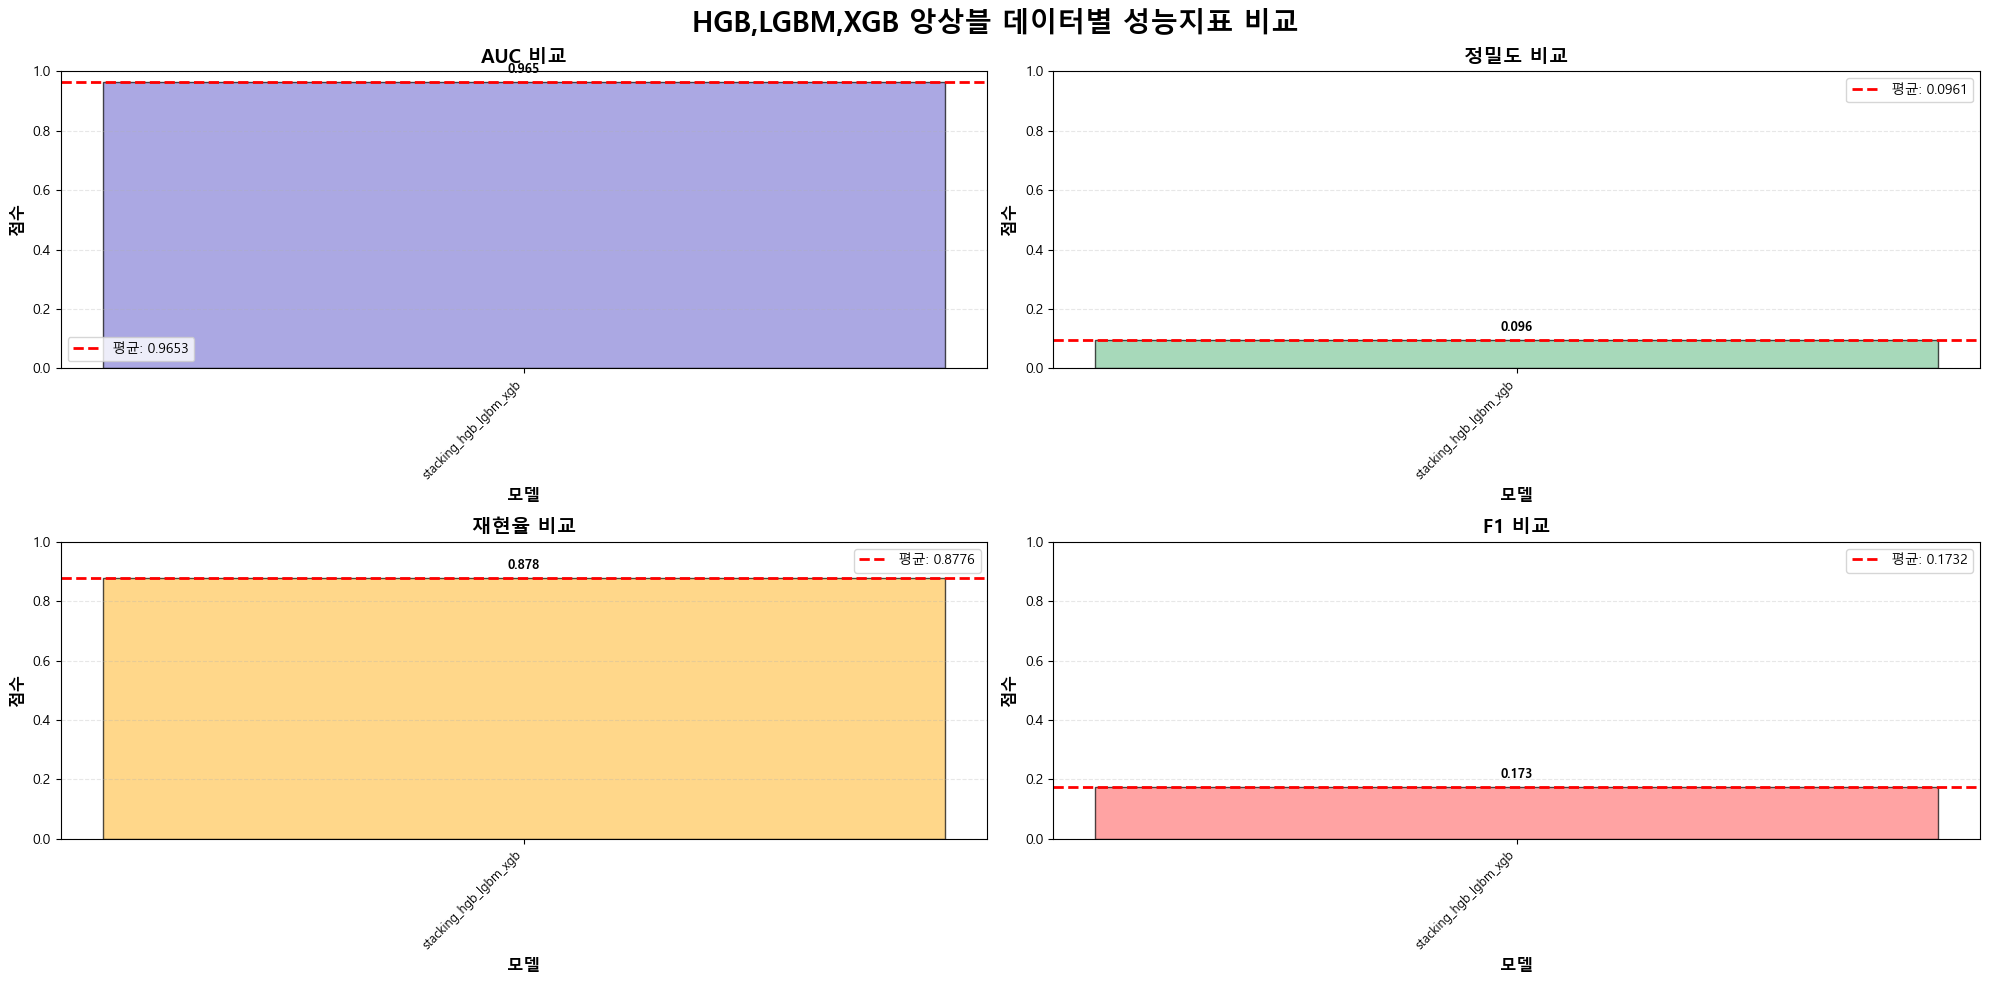


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9653 (stacking_hgb_lgbm_xgb)
  최저: 0.9653 (stacking_hgb_lgbm_xgb)
  평균: 0.9653
  표준편차: nan

[정밀도]
  최고: 0.0961 (stacking_hgb_lgbm_xgb)
  최저: 0.0961 (stacking_hgb_lgbm_xgb)
  평균: 0.0961
  표준편차: nan

[재현율]
  최고: 0.8776 (stacking_hgb_lgbm_xgb)
  최저: 0.8776 (stacking_hgb_lgbm_xgb)
  평균: 0.8776
  표준편차: nan

[F1]
  최고: 0.1732 (stacking_hgb_lgbm_xgb)
  최저: 0.1732 (stacking_hgb_lgbm_xgb)
  평균: 0.1732
  표준편차: nan


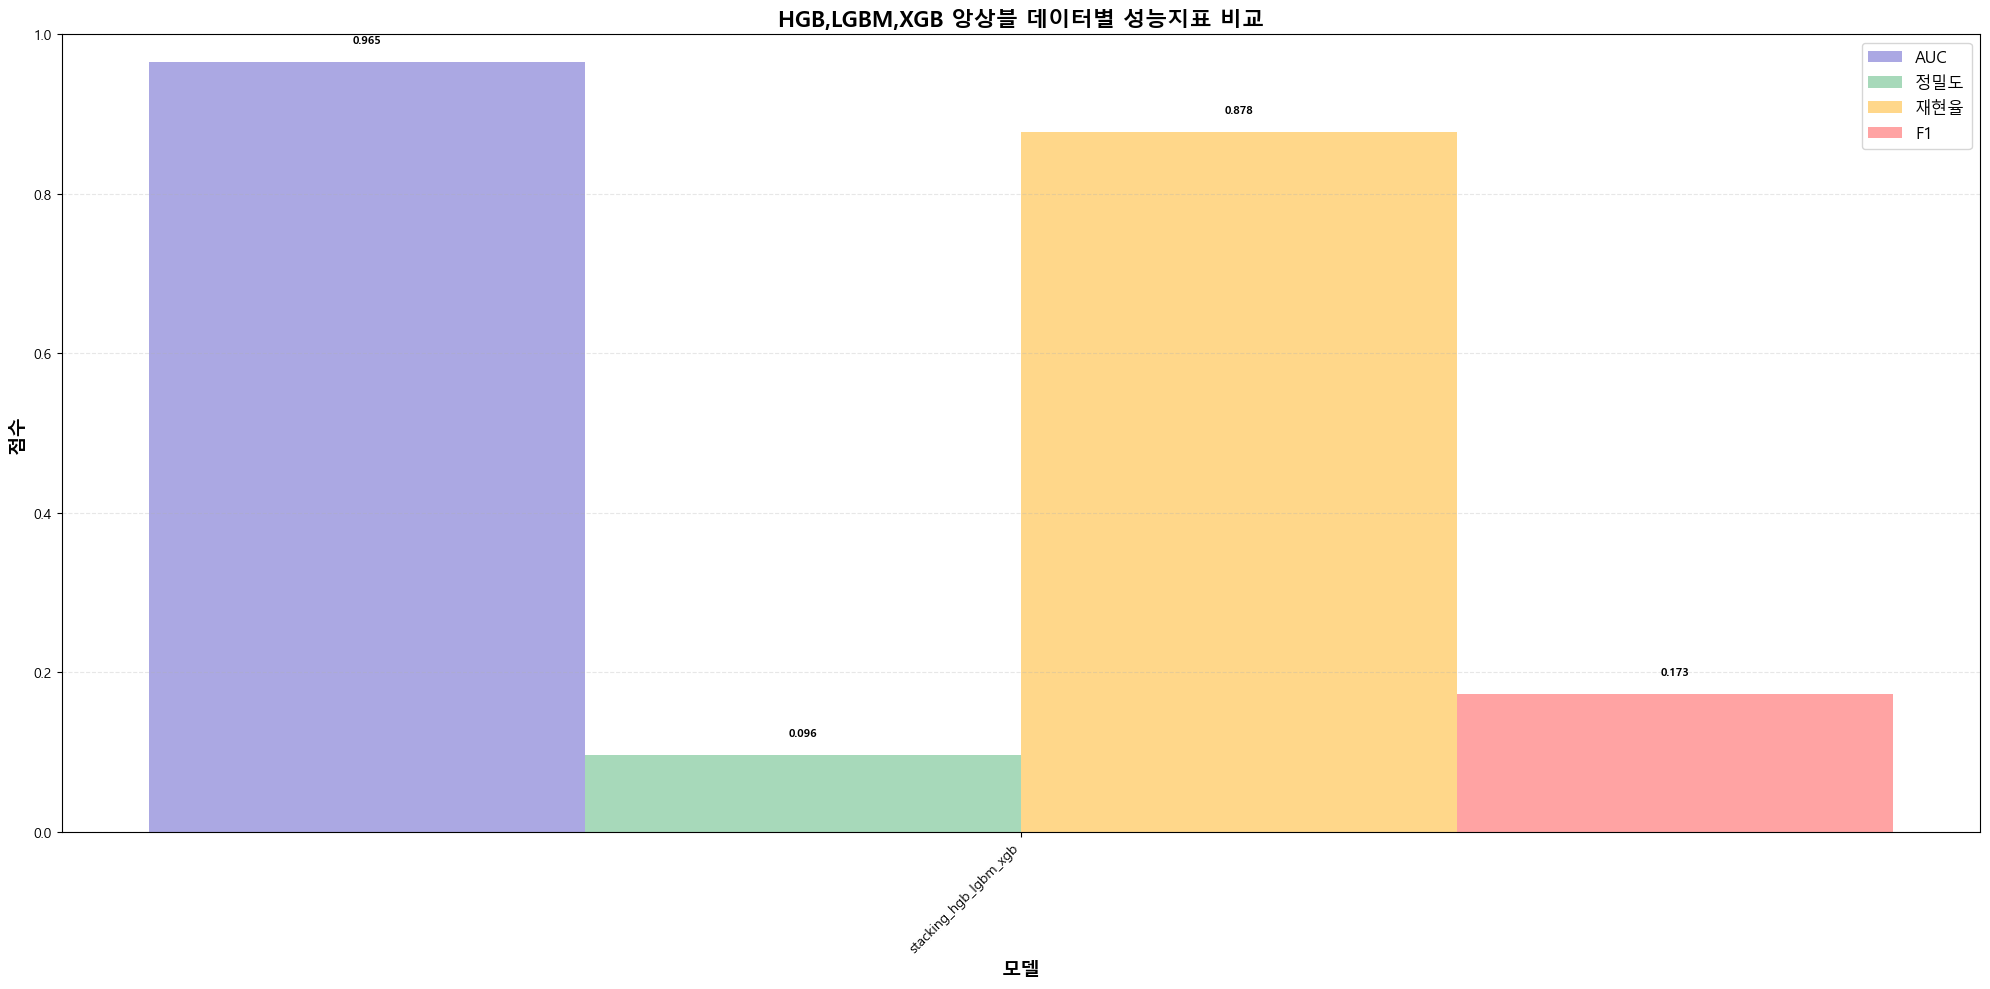


=== F1 Score 기준 상위 5개 모델 ===
[에러 발생] Column 'F1' has dtype object, cannot use method 'nlargest' with this dtype


In [112]:
mo.model_metrics_graph(results, 'HGB,LGBM,XGB 앙상블 데이터별 성능지표 비교')

최적 Threshold (F1 기준): 0.9998810916727779
최적 F1 Score: 0.6929824560913358
Classification Report (최적 threshold 적용):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.81      0.69        98

    accuracy                           1.00     56962
   macro avg       0.80      0.90      0.85     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9653094601656081
stacking_best_threshold 결과 저장 완료


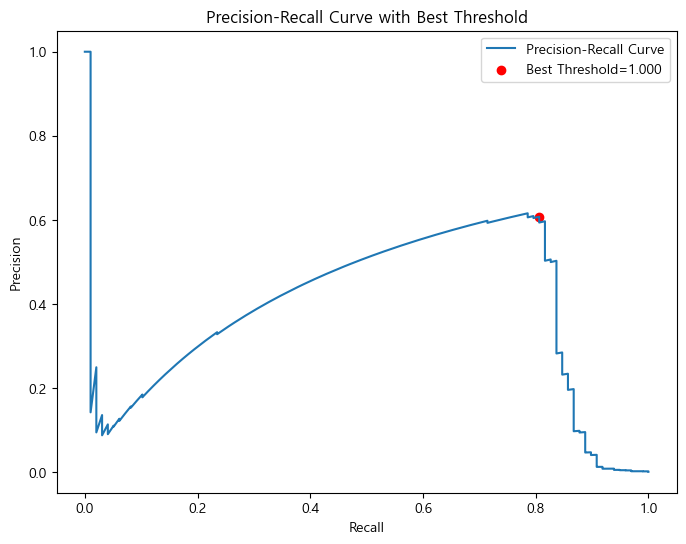

In [113]:
# Precision-Recall Curve + 최적 Threshold


from sklearn.metrics import precision_recall_curve

# Precision-Recall Curve 계산
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# F1 Score 계산
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)  # 0 나눗셈 방지

# 최적 threshold (F1 Score 최대값 기준)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print("최적 Threshold (F1 기준):", best_threshold)
print("최적 F1 Score:", f1_scores[best_idx])

# 최적 threshold 적용한 예측
y_pred_opt = (y_proba >= best_threshold).astype(int)

# 평가
print("Classification Report (최적 threshold 적용):\n", classification_report(y_test, y_pred_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# 결과 저장
model_name = "stacking_best_threshold"
results[model_name] = {
    "Threshold": best_threshold,
    "AUC": roc_auc_score(y_test, y_proba),
    "정확도": accuracy_score(y_test, y_pred_opt),
    "정밀도": precision_score(y_test, y_pred_opt),
    "재현율": recall_score(y_test, y_pred_opt),
    "F1": f1_score(y_test, y_pred_opt),
    "오차행렬": confusion_matrix(y_test, y_pred_opt).tolist()
}
print(f"{model_name} 결과 저장 완료")

# Precision-Recall Curve 시각화
plt.figure(figsize=(8,6))
plt.plot(recalls, precisions, label="Precision-Recall Curve")
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', label=f"Best Threshold={best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Best Threshold")
plt.legend()
plt.show()